Coefficient: 9423.815323030976
Intercept: 25321.583011776813

MAE: 6286.453830757749
MSE: 49830096.85590839
RMSE: 7059.04362190151
R2 Score: 0.9024461774180497


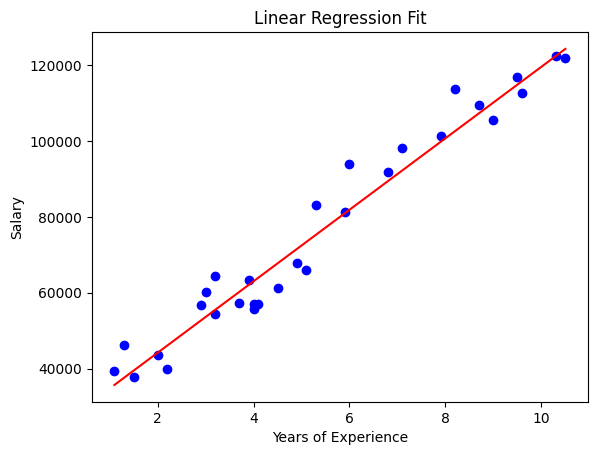

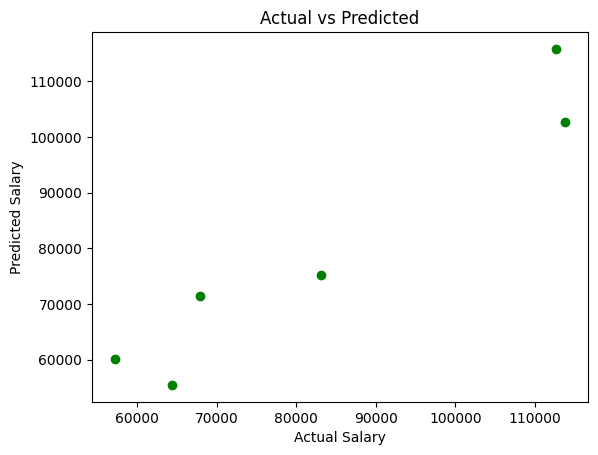

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("Salary_Data.csv")

# Features and target
X = df[['YearsExperience']]
y = df['Salary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model training
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Coefficients
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

# Evaluation
print("\nMAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

# Plot regression line
plt.scatter(X, y, color='blue')
plt.plot(X, model.predict(X), color='red')
plt.title("Linear Regression Fit")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

# Actual vs Predicted
plt.scatter(y_test, y_pred, color='green')
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
import numpy as np

# Data (convert to arrays)
X_gd = X.values.reshape(-1, 1)
y_gd = y.values

# Initialize parameters
m = 0
b = 0
learning_rate = 0.01
n = len(X_gd)

epochs = 1000

for i in range(epochs):
    y_pred = m * X_gd.flatten() + b

    # gradients
    dm = (-2/n) * sum(X_gd.flatten() * (y_gd - y_pred))
    db = (-2/n) * sum(y_gd - y_pred)

    # update parameters
    m = m - learning_rate * dm
    b = b - learning_rate * db

print("Final slope (m):", m)
print("Final intercept (b):", b)

Final slope (m): 9501.013219578916
Final intercept (b): 25448.181745946968


Learning Rate 0.001 → Final Loss: 135305790.73
Learning Rate 0.01 → Final Loss: 54049858.99
Learning Rate 0.1 → Final Loss: inf


/tmp/ipykernel_2451/2855410483.py:22: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_gd - y_pred) ** 2)


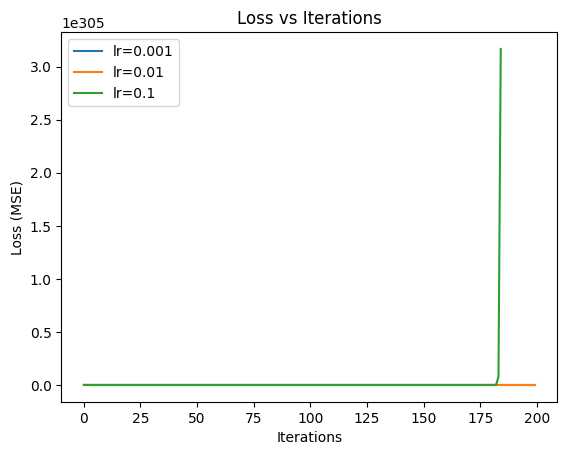

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
X_gd = X.values.reshape(-1, 1).flatten()
y_gd = y.values

n = len(X_gd)
epochs = 200

learning_rates = [0.001, 0.01, 0.1]
loss_history = {}

for lr in learning_rates:
    m, b = 0, 0
    losses = []

    for i in range(epochs):
        y_pred = m * X_gd + b

        # MSE loss
        loss = np.mean((y_gd - y_pred) ** 2)
        losses.append(loss)

        # gradients
        dm = (-2/n) * np.sum(X_gd * (y_gd - y_pred))
        db = (-2/n) * np.sum(y_gd - y_pred)

        # update
        m = m - lr * dm
        b = b - lr * db

    loss_history[lr] = losses
    print(f"Learning Rate {lr} → Final Loss: {losses[-1]:.2f}")

# Plot loss curves
for lr in learning_rates:
    plt.plot(loss_history[lr], label=f"lr={lr}")

plt.title("Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

Slow (0.001) → Final Loss: 135305790.73
Fast (0.01) → Final Loss: 54049858.99
Too High (0.5) diverged at iteration 1
Too High (0.5) → Final Loss: 8139023769361.11


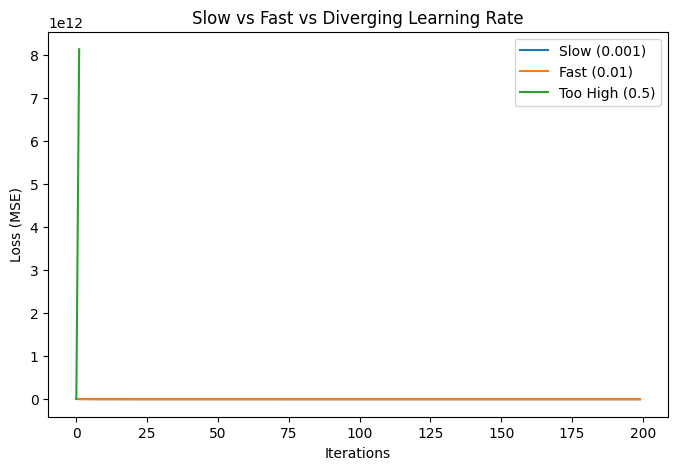

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
X_gd = X.values.reshape(-1, 1).flatten()
y_gd = y.values

n = len(X_gd)
epochs = 200

# Learning rates
learning_rates = {
    "Slow (0.001)": 0.001,
    "Fast (0.01)": 0.01,
    "Too High (0.5)": 0.5
}

loss_history = {}

for name, lr in learning_rates.items():
    m, b = 0, 0
    losses = []

    for i in range(epochs):
        y_pred = m * X_gd + b

        # Loss (MSE)
        loss = np.mean((y_gd - y_pred) ** 2)
        losses.append(loss)

        # Gradients
        dm = (-2/n) * np.sum(X_gd * (y_gd - y_pred))
        db = (-2/n) * np.sum(y_gd - y_pred)

        # Update parameters
        m = m - lr * dm
        b = b - lr * db

        # Stop if divergence detected (optional safety)
        if np.isnan(loss) or loss > 1e10:
            print(f"{name} diverged at iteration {i}")
            break

    loss_history[name] = losses
    print(f"{name} → Final Loss: {losses[-1]:.2f}")

# Plot results
plt.figure(figsize=(8,5))

for name in loss_history:
    plt.plot(loss_history[name], label=name)

plt.title("Slow vs Fast vs Diverging Learning Rate")
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# y_test with 6 values
y_test = pd.Series([10, 20, 30, 40, 50, 60])

# y_pred with SAME 6 values
y_pred = np.array([12, 18, 29, 41, 52, 58])

# Now this works
residuals = y_test - y_pred
print(residuals)

0   -2
1    2
2    1
3   -1
4   -2
5    2
dtype: int64
